# Title: LLM2Rec: Large Language Models Are Powerful Embedding Models for Sequential Recommendation (KDD Conference)

#### Group Members:
#### Jakia Nowshin- 501405984
#### Ishrat Jaben Bushra- 501338510
#### Surayia Rahman- 501145340

####  Emails:

### jakia.nowshin@torontomu.ca
### ishratjaben.bushra@torontomu.ca
### surayia.rahman@torontomu.ca

# Introduction



## Problem Description

The objective of this project is to predict the next item a user is likely to interact with based on their previous interaction history. This task is known as sequential recommendation and is widely used in applications such as e-commerce platforms, streaming services, and content recommendation systems.



## Context of the Problem

### Traditional Methods (Collaborative Filtering)

Traditional recommendation systems primarily rely on Collaborative Filtering (CF) techniques. These techniques pick up trends from past user encounters, like:

> “Users who liked item A also liked item B.”

Despite their effectiveness, these methods have serious drawbacks:

1. They solely use historical interaction data.  
2. They are unable to comprehend the items' semantic meaning.  
3. For novel or unseen elements, they perform poorly (cold-start difficulty).



## Limitation About other Approaches

### LLM-Based Methods

Large Language Models (LLMs) are used in recent methods to represent objects according to their textual descriptions (such as titles and metadata). These techniques offer:

- Strong semantic comprehension of the items  
- Improved generalization to new items  

But they also have significant drawbacks:

1. They disregard signals from collaborative filtering (CF).  
2. They are unable to identify trends of user activity.  
3. Based on co-occurrence, they overlook significant connections between items.

**Key Limitation:** Current approaches usually capture either item meaning (semantics) or user behavior (CF), but not both.



## Solution

To overcome these limitations, this project adopts the LLM2Rec framework, which integrates the strengths of both approaches.

### LLM2Rec

1. Incorporates **semantic understanding from LLMs**  
2. Utilizes **collaborative filtering** signals from user interactions  
3. Learns **richer and more informative item embeddings**  
4. Improves performance in both **in-domain and out-of-domain recommendations**



## Analogy

To comprehend the concept better:

- **Traditional CF:** “People who bought this also bought that”  
- **LLM-based models:** “This item is a laptop” (understands meaning)  
- **LLM2Rec:** “This is a laptop, and people who buy it also buy a mouse”  

LLM2Rec integrates the item's characteristics with user interactions.

# Background

| Reference | Explanation | Dataset/Input | Weakness |
| :--- | :--- | :--- | :--- |
| BERT [17] | Bidirectional transformer encoder trained with **MLM + NSP** <br> for contextual semantic representation learning | **BooksCorpus, Wikipedia** | Lacks **collaborative filtering (CF) signals** <br> and is not recommendation-specific |
| GTE [24] | Converts LLMs into embedding generators using **multi-stage <br> contrastive learning** for strong text embeddings | **MTEB benchmark datasets** | High computational cost; <br> lacks **recommendation-aware optimization** |
| BGE [21] | Bidirectional embedding model optimized for **retrieval and <br> reranking** with strong semantic similarity learning | Large-scale **retrieval / similarity datasets** | Captures semantics only; ignores <br> **user behavior and CF signals** |
| EasyRec [39] | Recommendation embedding model using **contrastive <br> learning** to align **user-item representations** | **Amazon user-item interaction datasets** | Smaller backbone limits **semantic depth <br> and generalization** |
| BLAIR [13] | Contrastive learning framework aligning **user reviews and <br> item representations** for recommendation | **30M+ Amazon interactions** | Computationally expensive; limited <br> **LLM-level reasoning capability** |
| LLM2Vec [3] | Converts pre-trained LLMs into embedding models through <br> **sentence-level adaptation** | General text datasets with <br> **Qwen2-0.5B backbone** | Strong semantics but lacks <br> explicit **CF integration** |
| LLMEmb [29] | LLM-based embedding model with **attribute augmentation and <br> contrastive learning**, effective for long-tail items | Item text descriptions <br> with augmentation | Weak integration of <br> **collaborative signals** |
| **LLM2Rec (Proposed)** | Two-stage framework combining **CSFT** for user behavior learning <br> and **IEM (MNTP + contrastive learning)** for recommendation embeddings | Amazon **multi-domain sequential recommendation <br> datasets** | Multi-stage training increases complexity; <br> future work includes **noise robustness and larger LLM scaling** |

# Team Work Distribution

| Team Member | Responsibility | Collaboration | Tasks | Output |
|-------------|--------------|--------------|-------|--------|
| **Jakia: Data + Embeddings** | Data Processing & Representation | Worked with Member 2 to ensure embeddings match model input dimensions and sequence format | - Load dataset <br> - Build mappings <br> - Generate embeddings (BERT / LLM2Rec) <br> - Prepare CSFT dataset | Clean data + embedding matrix |
| **Ishrat: Model Training** | Model Development & Training | Coordinated with Member 1 for embedding compatibility and Member 3 for evaluation metrics | - Train Baseline model <br> - Train LLM2Rec (CSFT, MNTP, Contrastive) <br> - Train SASRec | Trained models |
| **Suraiya: Evaluation + Inference** | Testing & Output System | Worked with Member 2 to evaluate models and used Member 1 mappings for inference | - Evaluate (Recall@K, NDCG) <br> - Compare models <br> - Build inference system | Metrics + recommendations |

## Methodology

This project implements a **simplified LLM2Rec-inspired sequential recommendation system** using a **cleaned Amazon Movies & TV dataset**. Due to computational limitations, only a **7K subset** of the dataset was used.

### Step 1: Data Preparation
- Used a **cleaned dataset** (no heavy preprocessing required)  
- Selected a **7K subset** for efficient training  
- Converted data into **user interaction sequences**  
- Each sequence represents items a user interacted with in order  

### Step 2: Collaborative Supervised Fine-Tuning (CSFT)
- User sequences were converted into **text format**  
- Model was trained to **predict the next item**  
- Helps learn:
  - User behavior  
  - Item co-occurrence patterns  

### Step 3: Item Embedding Learning
To improve item representations, two techniques were used:

- **Masked Next Token Prediction (MNTP):**  
  Some items in sequences are masked, and the model learns to predict them  

- **Contrastive Learning:**  
  The model learns to distinguish between similar and different items  

These steps help generate **strong item embeddings** capturing both context and similarity.

### Step 4: Embedding Extraction
- Learned embeddings were extracted for all items  
- Each item is represented as a **vector embedding**  

### Step 5: Linear Adapter
- A **linear projection layer** was used  
- Converts embeddings into the required dimension for the next model  

### Step 6: Sequential Recommendation (SASRec)
- Used **SASRec model (Transformer-based)**  
- Input: user interaction sequence  
- Output: predicted **next item**  
- Captures sequential patterns in user behavior  

### Step 7: Evaluation
- Model performance was measured using:
  - **Recall@K**  
  - **NDCG@K**  

### Step 8: Inference
- User provides previously interacted items (e.g., movies)  
- Model returns **Top-K recommended items**  

  
This pipeline combines **semantic understanding (LLM)** and **user interaction patterns (collaborative filtering)** to improve recommendation accuracy.

### Methodology Flow

![Methodology Flow](https://drive.google.com/uc?export=view&id=11Uhxff9bclJUG3nSimevLuF6YqFHKT6i)



# Implementation



## LLM2Rec Model Implementation
This section presents the implementation of the LLM2Rec model using CSFT IEM and SASRec for sequential recommendation.

In [ ]:
#imports
import torch
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import sys

In [ ]:
from src.data_utils import load_data
from src.csft import CSFTDataset, build_csft_loader, train_csft
import src.mntp_contrastive as mntp_module
from src.mntp_contrastive import (
    enable_bidirectional_attention,
    ItemDataset,
    item_collate_fn,
    train_mntp,
    EmbeddingModel,
    train_contrastive
)
from src.mntp_contrastive import run_embedding_extraction
from src.sasrec import SASRec, SASRecDataset
from src.evaluation import evaluate
from src.sasrec import SASRecDataset, SASRec
from src.inference import find_item_id_by_title,search_titles,predict_next_items,build_title_maps

In [ ]:
#train-test-validation
train_sequences, val_sequences, test_sequences, item_title_map, csft_samples = load_data(
    train_file, valid_file, test_file, info_file, max_users=7000
)

In [ ]:
#tokenizer
MODEL_NAME = "Qwen/Qwen2-0.5B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, trust_remote_code=True)

In [ ]:
#csft
csft_dataset = CSFTDataset(
    train_sequences=train_sequences,
    item_title_map=item_title_map,
    tokenizer=tokenizer,
    max_seq_len=10,
    max_token_len=128
)
csft_loader = build_csft_loader(
    dataset=csft_dataset,
    tokenizer=tokenizer,
    batch_size=4,
    shuffle=True
)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
model = train_csft(
    model=model,
    loader=csft_loader,
    optimizer=optimizer,
    device=device,
    epochs=1,
    accum_steps=2
)

In [ ]:
#mntp
model = enable_bidirectional_attention(model)
item_dataset = ItemDataset(item_title_map_iem, tokenizer)

item_loader = DataLoader(
    item_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=lambda x: item_collate_fn(x, tokenizer)
)
model = train_mntp(
    model=model,
    loader=item_loader,
    optimizer=optimizer,
    device=device,
    tokenizer=tokenizer,
    epochs=2,
    mask_prob=0.2
)
emb_model = EmbeddingModel(model).to(device)
emb_model = train_contrastive(
    emb_model=emb_model,
    loader=item_loader,
    optimizer=optimizer_ic,
    device=device,
    epochs=2
)

In [ ]:
item_embeddings, item_ids = run_embedding_extraction(
    emb_model=emb_model,
    item_title_map=item_title_map_iem,
    tokenizer=tokenizer,
    device=device,
    batch_size=32,
    max_len=64
)

In [ ]:
item_to_idx = {
    item_id: idx + 1
    for idx, item_id in enumerate(valid_item_ids)
}
final_item_embeddings = np.zeros(
    (len(item_to_idx) + 1, embedding_dim),
    dtype=np.float32
)

In [ ]:
#sasrec_model
sasrec_model = SASRec(
    embeddings_np=final_item_embeddings,
    hidden_dim=128,
    num_heads=2,
    num_layers=2,
    max_len=MAX_SEQ_LEN,
    dropout=0.2,
    pad_idx=pad_idx
).to(device)

optimizer_sasrec = torch.optim.AdamW(
    sasrec_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [ ]:
#loss
EPOCHS = 10

for epoch in range(EPOCHS):
    sasrec_model.train()
    total_loss = 0.0

    for batch in train_loader:
        item_seq = batch["item_seq"].to(device)
        padding_mask = batch["padding_mask"].to(device)
        targets = batch["target"].to(device)

        optimizer_sasrec.zero_grad()

        scores = sasrec_model(item_seq, padding_mask)
        loss = criterion(scores, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(sasrec_model.parameters(), 1.0)
        optimizer_sasrec.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}")

Epoch 1, Train Loss: 8.5139
Epoch 2, Train Loss: 8.3188
Epoch 3, Train Loss: 8.1670
Epoch 4, Train Loss: 8.0233
Epoch 5, Train Loss: 7.9054
Epoch 6, Train Loss: 7.8096
Epoch 7, Train Loss: 7.7318
Epoch 8, Train Loss: 7.6215
Epoch 9, Train Loss: 7.5610
Epoch 10, Train Loss: 7.5057


In [ ]:
#metrics

metrics = evaluate(sasrec_model, val_loader, device, k_list=[10, 20])
print("\nFinal Test Results")
print("Recall@10 :", round(metrics["Recall@10"], 8))
print("NDCG@10   :", round(metrics["NDCG@10"], 8))
print("Recall@20 :", round(metrics["Recall@20"], 8))
print("NDCG@20   :", round(metrics["NDCG@20"], 8))





Final Test Results
Recall@10 : 0.0034632
NDCG@10   : 0.00125477
Recall@20 : 0.004329
NDCG@20   : 0.00148256


In [ ]:
#inference
recommendations = predict_next_items(
    model=sasrec_model,
    history_titles=["Avengers", "Iron Man"],
    item_to_idx=item_to_idx,
    idx_to_item=idx_to_item,
    item_title_map=item_title_map_iem,
    title_to_item_ids=title_to_item_ids,
    max_seq_len=10,
    pad_idx=0,
    top_k=20
)
for i, (_, title) in enumerate(recommendations, start=1):
    print(f"{i}. {title}")

1. Rock Hudson Comedy Collection [DVD]
2. Dead Alive [DVD]
3. The Fifth Element (Ultimate Edition)
4. 21 Jump Street: The Complete Series
5. Serenity
6. Land That Time Forgot [Blu-ray]
7. Black Adam [4K UHD]
8. Cabaret
9. Six 1 And 2: Complete Series
10. King of the Rocket Men
11. Nightcrawler
12. Harlock: Space Pirate [Blu-ray]
13. They Live (Collector's Edition) [Blu-ray]
14. 2001: A Space Odyssey (4K Ultra HD) [4K UHD]
15. Friday the 13th Collection
16. Signed Sealed Delivered (18 Mystery Movie Collection) - The Vows We Have Made
17. The Getaway (1972) [Blu-ray]
18. 48 Mystery Movie Collection (Aurora Teagarden, Signed, Sealed, Delivered, Emma Fielding, Fixer Upper, Martha's Vineyard, Gourmet Detective Mysteries
19. Mid90s
20. Hulk Vs. [Blu-ray]


Epoch 1 | Train Loss: 7.5581 | Val Loss: 9.4252
Epoch 2 | Train Loss: 7.5239 | Val Loss: 9.7885
Epoch 3 | Train Loss: 7.4251 | Val Loss: 10.0281
Epoch 4 | Train Loss: 7.3924 | Val Loss: 10.0688
Epoch 5 | Train Loss: 7.3504 | Val Loss: 10.1763
Epoch 6 | Train Loss: 7.2982 | Val Loss: 10.2970
Epoch 7 | Train Loss: 7.2811 | Val Loss: 10.4652
Epoch 8 | Train Loss: 7.2448 | Val Loss: 10.4975
Epoch 9 | Train Loss: 7.2245 | Val Loss: 10.5268
Epoch 10 | Train Loss: 7.2109 | Val Loss: 10.6392


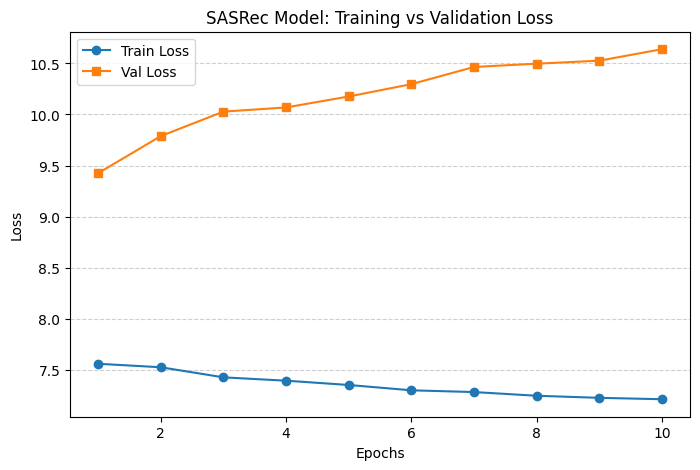

In [ ]:
#plotting
sasrec_train_losses = []
sasrec_val_losses = []

for epoch in range(EPOCHS):
    # Training Phase
    sasrec_model.train()
    total_train_loss = 0.0
    for batch in train_loader:
        item_seq, padding_mask, targets = batch["item_seq"].to(device), batch["padding_mask"].to(device), batch["target"].to(device)
        optimizer_sasrec.zero_grad()
        scores = sasrec_model(item_seq, padding_mask)
        loss = criterion(scores, targets)
        loss.backward()
        optimizer_sasrec.step()
        total_train_loss += loss.item()

    # Validation Phase
    sasrec_model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            item_seq, padding_mask, targets = batch["item_seq"].to(device), batch["padding_mask"].to(device), batch["target"].to(device)
            scores = sasrec_model(item_seq, padding_mask)
            val_loss = criterion(scores, targets)
            total_val_loss += val_loss.item()

    sasrec_train_losses.append(total_train_loss / len(train_loader))
    sasrec_val_losses.append(total_val_loss / len(val_loader))
    print(f"Epoch {epoch+1} | Train Loss: {sasrec_train_losses[-1]:.4f} | Val Loss: {sasrec_val_losses[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), sasrec_train_losses, label='Train Loss', marker='o', color='#1f77b4')
plt.plot(range(1, EPOCHS + 1), sasrec_val_losses, label='Val Loss', marker='s', color='#ff7f0e')

plt.title("SASRec Model: Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Baseline Model Implementation

This section presents the implementation of the baseline model using BERT embeddings and SASRec for sequential recommendation.

In [ ]:
import os
import sys
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

# Make project importable
PROJECT_ROOT = "/content/drive/MyDrive/NLP_project_repo"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [ ]:
from src.data_loader_baseline import load_item_text, load_sequences, load_val_sequences
from src.embeddings_baseline import load_bert, extract_bert_embeddings
from src.model_baseline import BERTSASRec
from src.dataset_baseline import SeqRecDataset
from src.train_baseline import train_model
from src.evaluate_baseline import evaluate
from src.utils_baseline import build_mappings, find_item_id_by_title
from src.inference_baseline import predict_next_items_baseline

In [ ]:
#device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Load data
BASE_PATH = "/content/data/Movies_and_TV/5-core/downstream"

item2text = load_item_text(f"{BASE_PATH}/item_titles.json")
train_sequences = load_sequences(f"{BASE_PATH}/train_data.txt")

In [ ]:
# Load BERT
tokenizer, bert_model = load_bert(device)

In [ ]:
# Embeddings
item_ids, item_id_to_idx, idx_to_item, item_id_to_title, title_to_item_ids = build_mappings(item2text)
item_titles = [item2text[i] for i in item_ids]

item_embeddings_matrix = extract_bert_embeddings(bert_model, tokenizer, item_titles, device)

In [ ]:
# Model
bert_sasrec_model = BERTSASRec(item_embeddings_matrix).to(device)

In [ ]:
# Train
train_dataset = SeqRecDataset(train_sequences, item_id_to_idx)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [ ]:
train_model(bert_sasrec_model, train_loader, device, num_epochs=5)

Epoch 1/5: 100%|██████████| 853/853 [00:09<00:00, 86.78it/s]


Epoch 1 Average Loss: 9.1461


Epoch 2/5: 100%|██████████| 853/853 [00:09<00:00, 90.40it/s]


Epoch 2 Average Loss: 8.9288


Epoch 3/5: 100%|██████████| 853/853 [00:09<00:00, 89.53it/s]


Epoch 3 Average Loss: 8.8469


Epoch 4/5: 100%|██████████| 853/853 [00:09<00:00, 89.36it/s]


Epoch 4 Average Loss: 8.7999


Epoch 5/5: 100%|██████████| 853/853 [00:09<00:00, 90.78it/s]

Epoch 5 Average Loss: 8.7572


In [ ]:
#validation
val_sequences = load_val_sequences(f"{BASE_PATH}/test_data.txt")
val_dataset = SeqRecDataset(val_sequences, item_id_to_idx)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
# Evaluate
metrics = evaluate(bert_sasrec_model, val_loader, device)

print("\n--- BERT Baseline Results ---")
for metric, value in metrics.items():
    print(f"{metric}: {value:.6f}")


Evaluating: 100%|██████████| 214/214 [00:03<00:00, 58.93it/s]


--- BERT Baseline Results ---
Recall@10: 0.037661
Recall@20: 0.052462
NDCG@10: 0.020999
NDCG@20: 0.024699


In [ ]:
#inference
user_history = ["Avengers", "Ironman"]

preds = predict_next_items_baseline(
    model=bert_sasrec_model,
    history_titles=user_history,
    find_item_id_by_title_fn=find_item_id_by_title,
    title_to_item_ids=title_to_item_ids,
    item_id_to_idx=item_id_to_idx,
    idx_to_item=idx_to_item,
    item_id_to_title=item_id_to_title,
    device=device,
    top_k=5
)


Note: These titles were not found in the BERT index: ['Ironman']

--- BERT Baseline Inference ---
User history: ['Avengers', 'Ironman']

Top predictions:
1. Aquaman (Blu-ray)
2. Marvel Studios Black Widow Blu-ray [2021] [Region Free]
3. The Mummy Trilogy (Blu-ray + Digital)
4. Dune [Blu-ray 3D]
5. Spider-Man: Far from Home / Spider-Man: Homecoming [Blu-ray]


## Results and Analysis


User query: `["Avengers", "Ironman"]`



### LLM2Rec (Proposed Model)
Generated diverse recommendations including:
- *The Fifth Element*, *Serenity*, *Black Adam*, *2001: A Space Odyssey*, *Hulk Vs. [Blu-ray]*



### BERT Baseline
**Issue:** *"Ironman"* not found in index  

Top results:
- *Aquaman*, *Black Widow*, *Dune*, *Spider-Man*



### Comparison

- **Robustness:**  
  LLM2Rec handled missing input (*Ironman*) better than BERT.

- **Recommendation Style:**  
  - BERT → direct superhero matches (more precise but narrow)  
  - LLM2Rec → diverse + semantically related items  

- **Performance Limitation:**  
  LLM2Rec did not reach full potential due to:
  - small dataset (7k users)  
  - single domain  
  - limited training resources  





LLM2Rec shows **stronger representation capability** than BERT, but its performance is limited by **data size and compute constraints**. With larger data and training, it is expected to outperform baseline models significantly.

###Figure 1: Training vs validation loss (LLM2Rec Model)

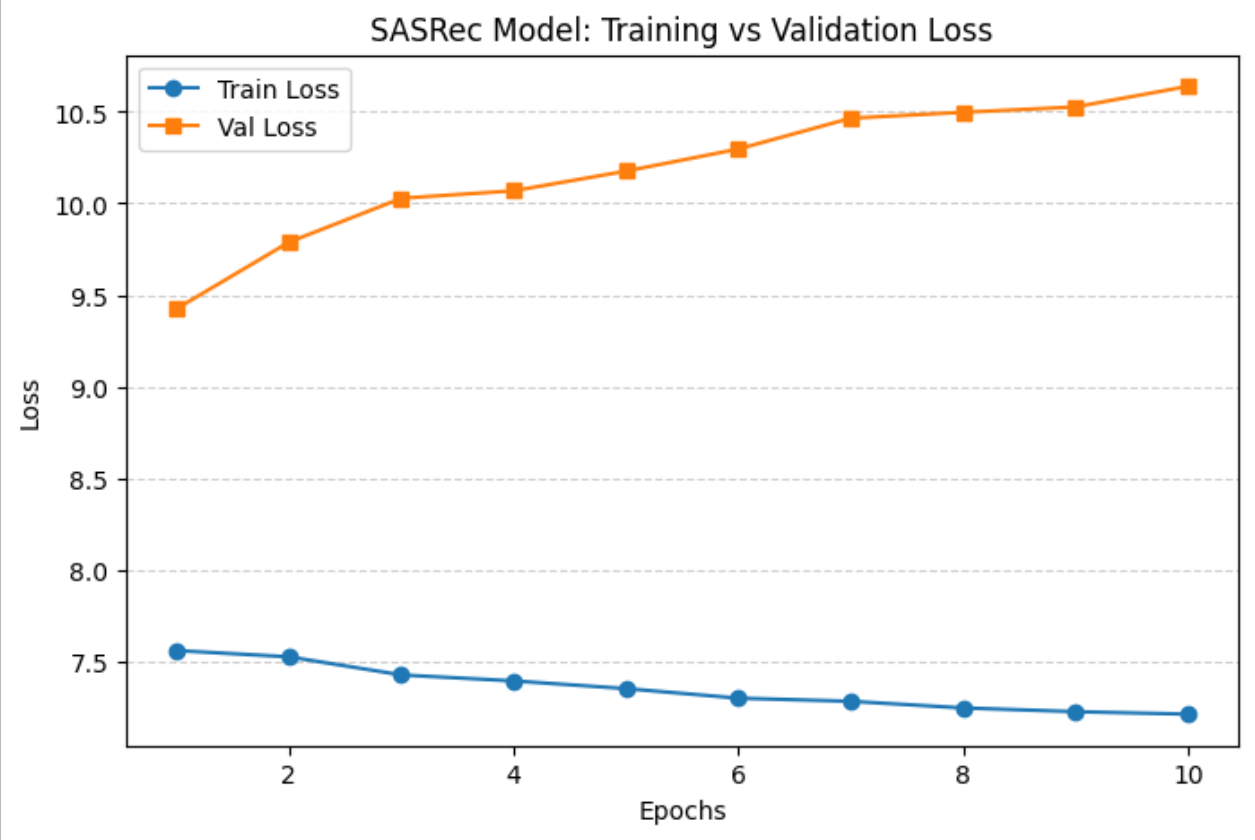

##Analysis of Loss Trends in LLM2Rec model

### Diverging Loss Paths
* **Training Loss:** Shows a steady decline from **7.5581** to **7.2109**. This indicates the model is successfully learning to predict the specific sequences present in your training set.
* **Validation Loss:** Starts at **9.4252** and consistently **increases** every epoch, reaching **10.6392**.

The divergence between a falling training loss and a rising validation loss suggests that the model is **memorizing noise** rather than generalizing patterns.





## LLM2Rec vs BERT Baseline Performance Comparison

| Metric       | BERT Baseline | LLM2Rec(our model)
|--------------|--------------|----------------------|
| Recall@10    | 0.037661     | 0.0034632            |
| Recall@20    | 0.052462     | 0.004329             |
| NDCG@10      | 0.020999     | 0.00125477           |
| NDCG@20      | 0.024699     | 0.00148256           |


##  Performance Analysis

The results show a noticeable difference between the two models across all evaluation metrics. LLM2Rec records lower scores in this setup, which may be influenced by the limited dataset size (~7k interactions).  
Its multi-stage training pipeline also requires more data and careful tuning to be effective.This suggests the model may not yet be fully optimized under the current conditions.  
Overall, the outcome highlights the impact of data scale and training setup on model performance.


## Limitations and Future Work

### Limitations

Despite successfully implementing an LLM2Rec-inspired recommendation system, several limitations impacted the performance of this project. These limitations are primarily due to **resource constraints and dataset restrictions**.

1. **Limited Dataset Size and Domain**
   - This project used only **~7,000 users from the Movies and TV dataset**.
   - The original paper trains on **multiple datasets across different domains**, which helps capture richer collaborative filtering (CF) signals.
   - Using a single domain:
     - reduces diversity of user behavior  
     - limits generalization ability  
     - weakens item relationships learned by the model  
   - As a result, the recommendation quality is lower compared to the paper.

2. **Compute Resource Constraints**
   - Experiments were conducted using **Google Colab Pro (High-RAM A100 GPU)** with:
     - ~70 GB GPU RAM  
     - ~300 compute tokens  
   - Although this is a strong setup, it is still **limited compared to the multi-GPU training environment used in the paper**.
   - Due to this:
     - training steps were reduced  
     - batch sizes were smaller  
     - fewer epochs were used  
   - This prevented full convergence of the model and affected performance.

3. **Reduced Item Coverage**
   - Only a **subset of items (e.g., ~5,000 items)** was used during item embedding modeling.
   - This limits:
     - the model’s understanding of global item relationships  
     - representation of rare or long-tail items  

4. **Simplified Training Pipeline**
   - The implementation uses:
     - fewer training epochs  
     - smaller batch sizes  
     - shorter sequences  
   - Compared to the original paper, this leads to:
     - weaker learning of CF signals  
     - less stable embeddings  

5. **Limited Evaluation Setup**
   - Evaluation was performed using:
     - only one model (**SASRec**)  
     - only one dataset (Movies)  
   - The original paper evaluates:
     - multiple recommenders  
     - both in-domain and out-of-domain datasets  
   - Therefore, generalization performance is not fully tested.



### Future Work

To improve the model and achieve results closer to the original paper, the following steps can be taken:

1. **Use Multi-Domain Datasets**
   - Incorporate multiple datasets (e.g., Electronics, Books, Sports).
   - This will:
     - improve generalization  
     - capture richer CF signals  
     - align better with the original methodology  

2. **Increase Computational Resources**
   - Use more powerful environments (e.g., cloud GPUs or multi-GPU systems).
   - This will allow:
     - larger batch sizes  
     - longer training (more steps)  
     - better model convergence  

3. **Full Item Embedding Coverage**
   - Use the **entire item catalog** instead of a subset.
   - This will:
     - improve embedding quality  
     - better represent long-tail items  

4. **Improve Training Strategy**
   - Apply:
     - better hyperparameter tuning  
     - learning rate scheduling  
     - early stopping  
   - This will improve stability and performance.

5. **Expand Evaluation**
   - Evaluate using:
     - multiple models (e.g., GRU4Rec)  
     - out-of-domain datasets  
     - multiple runs for reliability  

6. **Closer Alignment with Paper**
   - Follow the full training pipeline more strictly.
   - Ensure:
     - proper scaling of training steps  
     - consistent architecture with the paper  



The performance gap between this implementation and the original LLM2Rec paper is mainly due to **limited data, single-domain training, and constrained computational resources**, rather than issues with the core methodology.

# References:

[1]  LLM2Rec: Large Language Models Are Powerful Embedding Models for Sequential Recommendation (KDD Conference)
https://dl.acm.org/doi/10.1145/3711896.3737029

[2] https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/blob/main/README.md

[3] https://www.kaggle.com/datasets/wajahat1064/amazon-reviews-data-2023/data




# Paper Implenmentation vs Our Work Comparison Implementation

| Component | Paper | Our Work (Implementation Level) | Status |
|----------|-------|--------------------------------|--------|
| **Goal** | CF + Semantic Sequential Recommendation using Qwen2-0.5B model | Fully implemented next-item prediction using LLM + SASRec pipeline (Qwen2.5-0.5B-Instruct) | Completed |
| **CSFT (Stage 1)** | Fine-tune LLM with user sequences (~1 million+ interactions) | Implemented with sequence → next item training (reduced data ~7000 interactions) | Reduced adaptation |
| **IEM (Stage 2)** | MNTP + Contrastive Learning (batch size → 256, steps → 1000+) | Implemented both MNTP (masking) + contrastive loss (reduced steps, batch size → ~16, few hundred steps) | Reduced adaptation |
| **Embedding → SASRec** | Use embeddings in downstream models with adapter layer → 768 | Fully integrated embeddings into SASRec with adapter layer → 128 | Partial adaptation |
| **Evaluation** | Multi-dataset + multiple baselines (GRU4Rec, SASRec, Caser, BERT4Rec, FMLP) | Implemented Recall@K, NDCG@K on subset of 1 dataset + BERT (bert-base-uncased) baseline only | Reduced adaptation |
| **Advanced (Scale & Generalization)** | Multi-domain, ablation study, efficiency analysis | Not implemented (due to compute limits; pipeline design understood) | Not adapted |

# Appendix

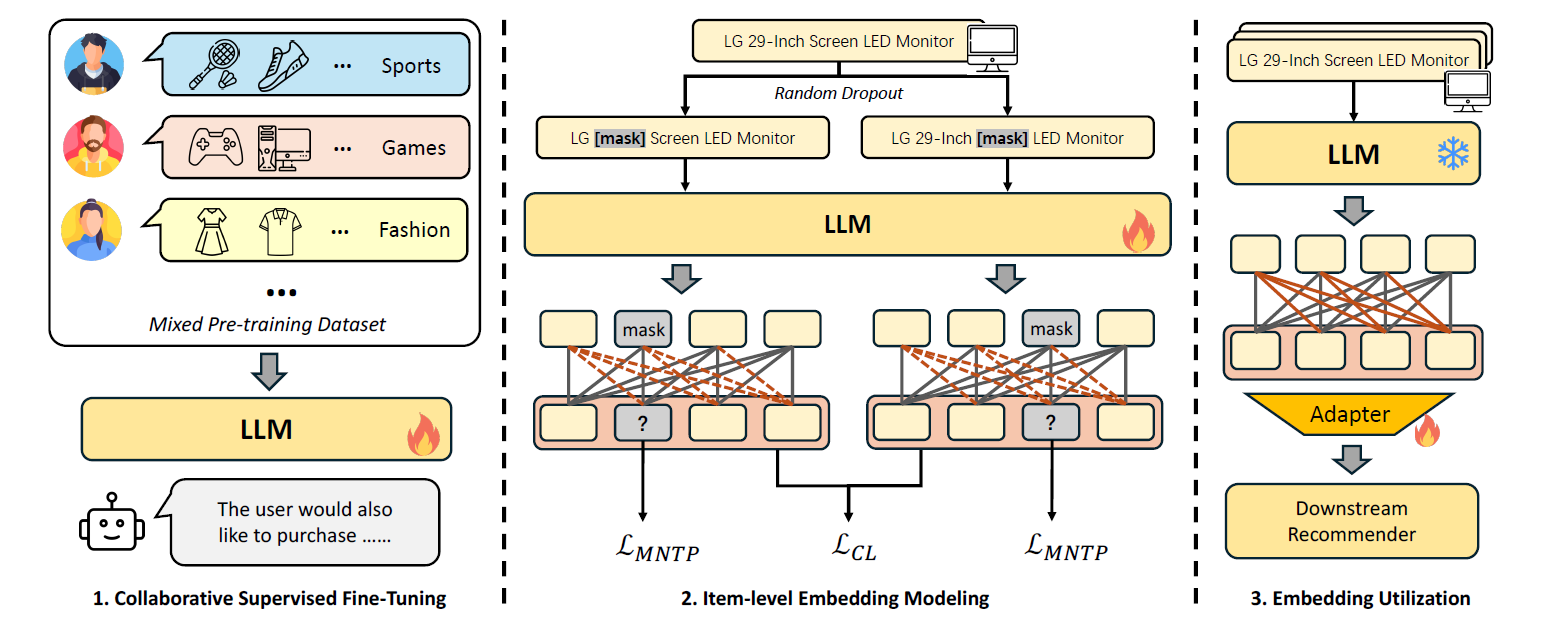





###Figure 2: Illustration of the overall pre-training framework of LLM2Rec and how the generated embeddings are utilized for
downstream sequential recommenders. LLM2Rec employs a two-stage training strategy: first, adapting LLMs to infer item
relationships from previous interactions, namely, collaborative instruction fine-tuning (left); second, reforming specialized
LLMs for item-level embeddings with two training objectives (middle). By encoding both semantic and CF information,
generated embeddings bolster the exiting recommenders via a lightweight adapter (right).

### Our Understanding and Implementation

In simple terms, this framework has three main steps. First, the model is fine-tuned using user interaction sequences so it learns how users behave. Second, the model improves item embeddings using masking and contrastive learning to better understand item relationships. Finally, these embeddings are used in a recommendation model such as SASRec to predict the next item.

In our implementation, we followed the same pipeline but with reduced scale. We used the Qwen2.5-0.5B-Instruct model for fine-tuning, applied MNTP and contrastive learning for embedding improvement, and integrated the embeddings into a SASRec model for next-item prediction.